In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, accuracy_score,
    precision_score, recall_score, f1_score, roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV

## Dataset Prepration

In [2]:
df=pd.read_csv(r'~\avalanche_sat\Data\full_dataset.csv')
# Drop non-numeric columns and missing data
df_numeric = df.select_dtypes(include=["number"]).dropna(axis=1).drop(columns=['year'])

# Split features and target
X = df_numeric.drop(columns=["avalancheDay1"])
y = df_numeric["avalancheDay1"]

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# PCA 

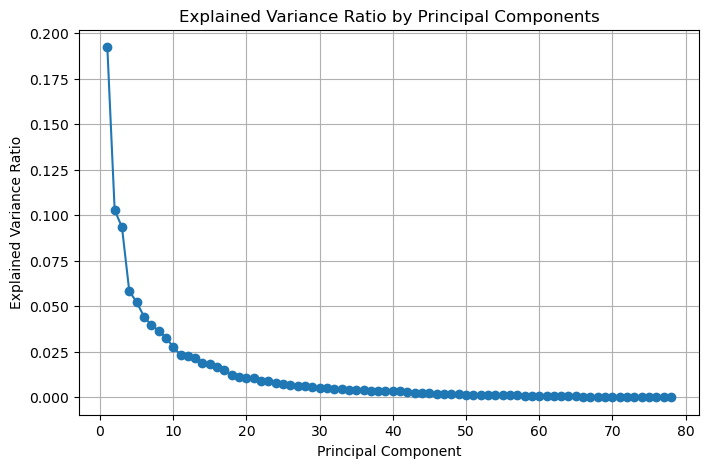

In [3]:

# Apply PCA
pca = PCA()
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Analyze variance
explained_variance_ratio = pca.explained_variance_ratio_

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker='o')
plt.title('Explained Variance Ratio by Principal Components')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()


In [4]:
np.cumsum(explained_variance_ratio)[[0, 1, 2, 25]]

array([0.19231147, 0.29513946, 0.3885477 , 0.90047801])

## KNN

               Best n_neighbors  Train Accuracy  Test Accuracy  Precision  \
1_components               14.0        0.952470       0.951606   0.681319   
2_components               15.0        0.958301       0.958645   0.733333   
3_components                7.0        0.966993       0.962604   0.741667   
25_components               5.0        0.985697       0.981082   0.903226   

                 Recall  F1 Score  
1_components   0.433566  0.529915  
2_components   0.538462  0.620968  
3_components   0.622378  0.676806  
25_components  0.783217  0.838951  


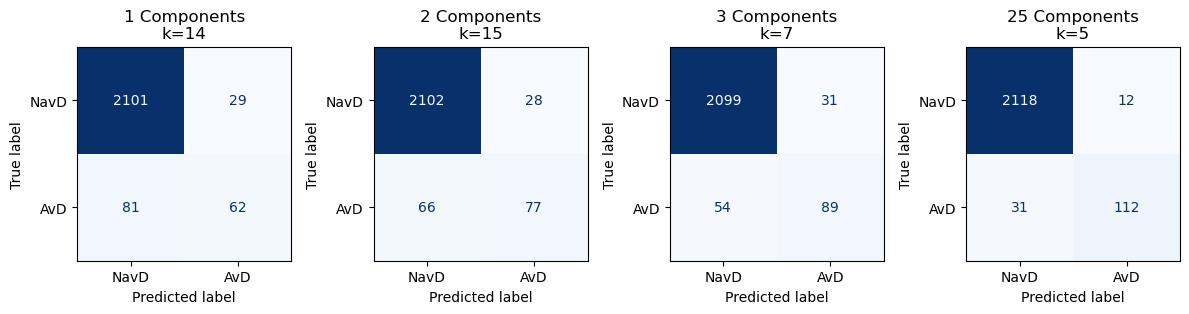

In [6]:


# Initialize dictionary to store results
results = {}

# Create subplots
fig, ax = plt.subplots(nrows=1, ncols=4, figsize=(12, 3))

# Loop through different numbers of PCA components
for i, n_components in enumerate([1, 2, 3, min(25, X_train_scaled.shape[1])]):
    
    # Define pipeline
    pipe = Pipeline([
        ('pca', PCA(n_components=n_components)),
        ('knn', KNeighborsClassifier())
    ])
    
    # Define parameters to tune
    param_grid = {
        'knn__n_neighbors': list(range(1, 16))  # Trying n_neighbors from 1 to 15
    }
    
    # Grid Search
    grid = GridSearchCV(pipe, param_grid, cv=5)
    grid.fit(X_train_scaled, y_train)
    
    # Best model
    best_pipe = grid.best_estimator_
    best_n_neighbors = grid.best_params_['knn__n_neighbors']
    
    # Predictions
    y_pred = best_pipe.predict(X_test_scaled)
    
    # Scores
    train_score = best_pipe.score(X_train_scaled, y_train)
    test_score = best_pipe.score(X_test_scaled, y_test)
    
    # Save metrics
    results[f'{n_components}_components'] = {
        'Best n_neighbors': best_n_neighbors,
        'Train Accuracy': train_score,
        'Test Accuracy': test_score, 
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    }
    
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot confusion matrix
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["NavD", "AvD"])
    disp.plot(cmap='Blues', values_format='d', ax=ax[i], colorbar=False)
    ax[i].set_title(f'{n_components} Components\nk={best_n_neighbors}')

# Adjust layout
plt.tight_layout()

# Display results
results_df = pd.DataFrame(results).T
print(results_df)
